In [3]:
import os
import pickle
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import glob
from cross_group_functions import fish_mid, file_fish_cross, dbscan_dist

In [4]:
load_dotenv()

True

C:\Users\BDDea\AppData\Local\Temp\ipykernel_24916\3524230478.py:9: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  t1 = pickle.load(open(t, 'rb'))


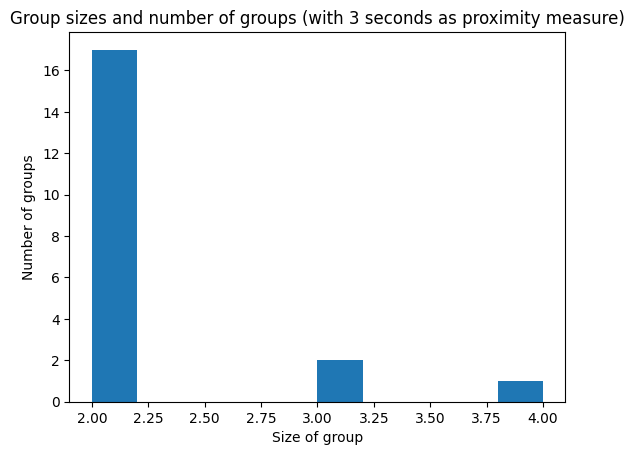

In [ ]:
tracks_folder = os.environ.get("TRACKS_OUTPUT")

track_files = sorted(glob.glob(os.path.join(
    tracks_folder, f"2025-08-07-tracks-class-3-clip-*.pkl")))

tracks = {}
for i in range(len(track_files)):
    t = os.path.join(tracks_folder, f"{track_files[i]}")
    t1 = pickle.load(open(t, 'rb'))
    tracks[i] = t1

for file in tracks:
    tracks[file] = fish_mid(tracks[file])

left_right, right_left = file_fish_cross(tracks, 1500)

rl_groups = []
for file in right_left:
    if len(right_left[file]) == 1:
        continue
    groups = dbscan_dist(right_left[file], 45)
    if groups:
        rl_groups.append(groups)

histo = []
for groups in rl_groups:
    for group in groups:
        histo.append(len(group))

plt.hist(histo)
plt.title('Group sizes and number of groups (with 3 seconds as proximity measure)')
plt.xlabel('Size of group')
plt.ylabel('Number of groups')
plt.show()

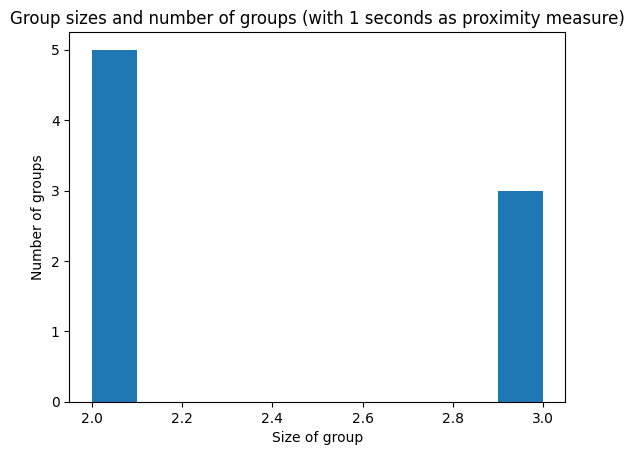

In [7]:
rl_groups = []
for file in right_left:
    if len(right_left[file]) == 1:
        continue
    groups = dbscan_dist(right_left[file], 15)
    if groups:
        rl_groups.append(groups)

histo = []
for groups in rl_groups:
    for group in groups:
        histo.append(len(group))

plt.hist(histo)
plt.title('Group sizes and number of groups (with 1 seconds as proximity measure)')
plt.xlabel('Size of group')
plt.ylabel('Number of groups')
plt.show()

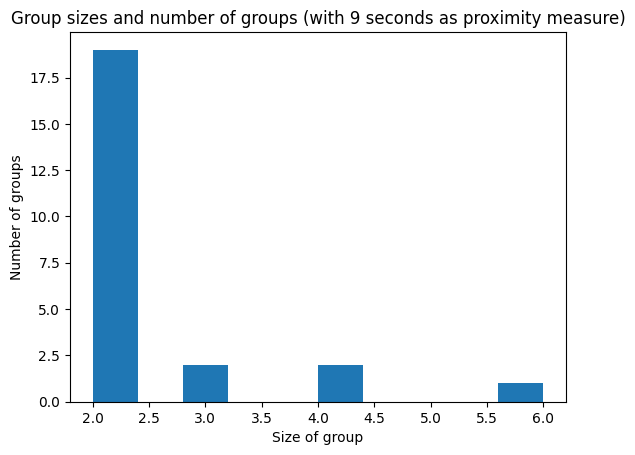

In [8]:
rl_groups = []
for file in right_left:
    if len(right_left[file]) == 1:
        continue
    groups = dbscan_dist(right_left[file], 135)
    if groups:
        rl_groups.append(groups)

histo = []
for groups in rl_groups:
    for group in groups:
        histo.append(len(group))

plt.hist(histo)
plt.title('Group sizes and number of groups (with 9 seconds as proximity measure)')
plt.xlabel('Size of group')
plt.ylabel('Number of groups')
plt.show()